In [2]:
import os

os.chdir("..")
from fourm.data.multimodal_dataset_folder import MultiModalDatasetFolder
from fourm.data.modality_transforms import DepthTransform, UnifiedDataTransform
from fourm.data.image_augmenter import RandomRotationImageAugmenter

In [ ]:
# depth only
depth_transform = DepthTransform(standardize_depth=False)
MODALITY_TRANSFORMS_DIVAE = {"depth": depth_transform}
image_augmenter_train = RandomRotationImageAugmenter(near_orthogonal=False)
# all modalities
transforms_train = UnifiedDataTransform(
    transforms_dict=MODALITY_TRANSFORMS_DIVAE,
    image_augmenter=image_augmenter_train,
    add_sizes=False,
)
# TODO: test with RGB
dataset_train = MultiModalDatasetFolder(
    root="/data/million-case/train",
    modalities=["depth"],
    modality_paths={"depth": "depth"},
    modality_transforms=MODALITY_TRANSFORMS_DIVAE,
    transform=None,
    cache=False,
)
dataset_train

Dataset MultiModalDatasetFolder
    Number of datapoints: 1033790
    Root location: /data/million-case/train

In [ ]:
dataset_train[0]["depth"]

<PIL.TiffImagePlugin.TiffImageFile image mode=F size=512x512>

<Figure size 640x480 with 0 Axes>

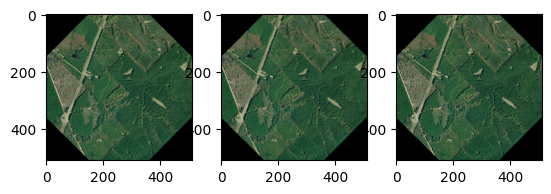

In [3]:
from PIL import Image
import torchvision.transforms.functional as TF
from matplotlib import pyplot as plt

im = Image.open("/scratch/bdej/cohanlon/unlabeled/train/rgb/million-case/NAIP_220683.jpg")
im1 = TF.rotate(im, 45.4, Image.Resampling.NEAREST)
im2 = TF.rotate(im, 45.4, Image.Resampling.BILINEAR)
im3 = TF.rotate(im, 45.4, Image.Resampling.BICUBIC)

plt.figure()
f, axarr = plt.subplots(1, 3)
axarr[0].imshow(im1)
axarr[1].imshow(im2)
axarr[2].imshow(im3)

plt.show()

In [3]:
from fourm.data.modality_transforms import RGBTransform
from fourm.data.modality_info import MODALITY_INFO
import torch


def setup_modality_info(args):
    """Sets up the modality info dictionary for the given domains."""
    modality_info = {mod: MODALITY_INFO[mod] for mod in args}
    return modality_info


modality_info = setup_modality_info(["rgb"])
modality_paths = {"rgb": "rgb"}

MODALITY_TRANSFORMS_DIVAE = {}
MODALITY_TRANSFORMS_DIVAE["rgb"] = RGBTransform(
    mean_and_std="naip", color_jitter=False, no_data_value=0
)

image_augmenter_train = RandomRotationImageAugmenter(near_orthogonal=True)

transforms_train = UnifiedDataTransform(
    transforms_dict=MODALITY_TRANSFORMS_DIVAE,
    image_augmenter=image_augmenter_train,
    resample_mode="bicubic",
    add_sizes=False,
)

dataset_train = MultiModalDatasetFolder(
    root="/scratch/bdej/cohanlon/unlabeled/train",
    modalities=["rgb", "mask_valid"],
    modality_paths=modality_paths,
    modality_transforms=MODALITY_TRANSFORMS_DIVAE,
    modality_info=modality_info,
    transform=transforms_train,
    cache=False,
)

sampler_train = torch.utils.data.DistributedSampler(
    dataset_train,
    num_replicas=1,
    rank=0,
    shuffle=True,
    drop_last=True,
)

data_loader_train = torch.utils.data.DataLoader(
    dataset_train,
    sampler=sampler_train,
    batch_size=64,
    num_workers=1,
    pin_memory=False,
    drop_last=True,
)

In [7]:
import time

start = time.time()
for i in range(4):
    next(iter(data_loader_train))
print(time.time() - start)


21.816264152526855


In [14]:
dataset_train.class_to_idx

{'sar': 0, 'million-case': 1}